In [72]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fertilizer-recommendation/fertilizer_recommendation_dataset.csv


In [75]:
import pandas as pd
df = pd.read_csv('/kaggle/input/fertilizer-recommendation/fertilizer_recommendation_dataset.csv')
print(df.shape)
df.head(10)


(3100, 12)


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."
5,50.179845,0.227436,275.544796,8.828433,74.990641,128.631682,129.099985,0.843296,Loamy Soil,rice,Gypsum,"Corrects alkaline soil, adds calcium and sulfu..."
6,22.386834,0.227436,292.745108,5.902666,78.814989,60.471726,66.060843,1.518379,Peaty Soil,rice,Lime,Neutralizes acidic soil and improves pH balanc...
7,21.342227,0.785753,249.980185,5.692240,72.089121,42.591255,68.035609,2.410625,Peaty Soil,rice,DAP,"Rich in phosphorus, essential for root develop..."
8,25.657999,0.756739,250.701012,6.614611,75.032505,118.005348,142.004742,-0.280560,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
9,21.296925,0.783450,211.049382,6.386646,72.711484,68.352057,94.695401,2.464714,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [76]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB


Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64

In [77]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Temperature,3100.0,27.271096,9.114450,4.011486,22.408505,26.132938,29.987887,56.653592
Moisture,3100.0,0.600763,0.144947,0.227436,0.493595,0.599520,0.708575,0.972361
Rainfall,3100.0,111.024949,77.151880,-85.709593,61.283985,96.485935,147.619401,411.955947
PH,3100.0,6.379775,0.957103,3.448974,5.860489,6.337308,6.899739,9.562341
Nitrogen,3100.0,61.278480,10.186410,35.527718,54.835715,59.429649,65.792790,98.581039
Phosphorous,3100.0,69.582850,42.226712,-37.649739,43.039260,58.205269,86.108983,177.314481
Potassium,3100.0,69.721167,35.304241,-20.509108,49.992405,58.710808,76.318626,161.067982
Carbon,3100.0,1.474325,0.698300,-0.280560,0.956401,1.463357,2.003534,3.241984


In [78]:
print("Crops:", df['Crop'].nunique())
print(df['Crop'].value_counts())



Crops: 31
Crop
rice            100
Moth Beans      100
pomegranate     100
papaya          100
orange          100
muskmelon       100
mango           100
apple           100
grapes          100
banana          100
Chickpea        100
Pigeon Peas     100
Adzuki Beans    100
Black gram      100
Coconut         100
Kidney Beans    100
wheat           100
Tobacco         100
Sugarcane       100
Rubber          100
Peas            100
Ground Nut      100
Cotton          100
Coffee          100
Jute            100
Lentil          100
maize           100
millet          100
Tea             100
Mung Bean       100
watermelon      100
Name: count, dtype: int64


In [79]:
print(df.columns)


Index(['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous',
       'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer', 'Remark'],
      dtype='object')


In [80]:
# Crop-wise recommended fertilizers
print(df.groupby('Crop')['Fertilizer'].value_counts())


Crop          Fertilizer                
Adzuki Beans  DAP                           41
              Water Retaining Fertilizer    17
              Compost                       12
              Balanced NPK Fertilizer        8
              Muriate of Potash              8
                                            ..
wheat         Compost                       14
              Urea                           4
              General Purpose Fertilizer     2
              Lime                           2
              Muriate of Potash              2
Name: count, Length: 250, dtype: int64


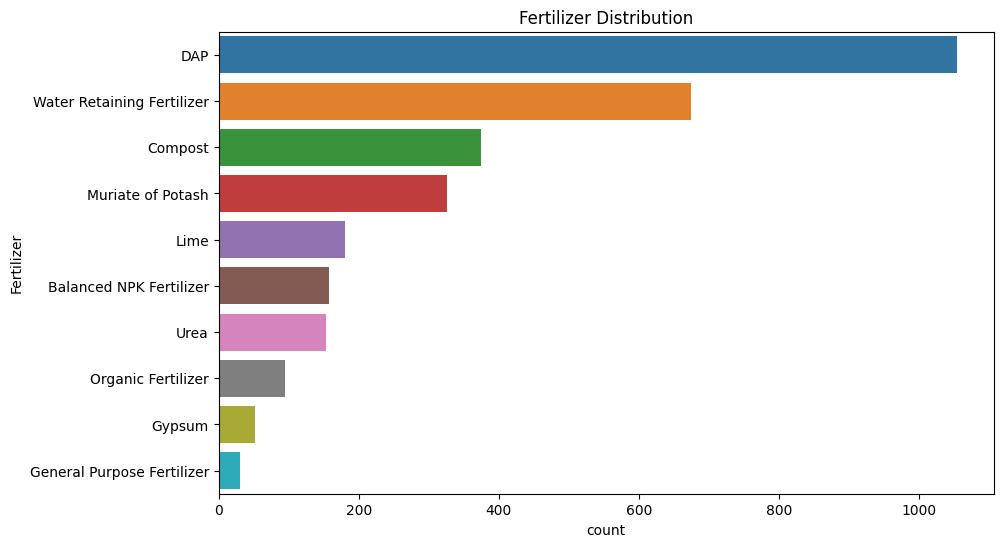

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(y='Fertilizer', data=df, order=df['Fertilizer'].value_counts().index)
plt.title("Fertilizer Distribution")
plt.show()


In [82]:
print(df['Fertilizer'].value_counts())


Fertilizer
DAP                           1054
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              326
Lime                           181
Balanced NPK Fertilizer        157
Urea                           154
Organic Fertilizer              95
Gypsum                          52
General Purpose Fertilizer      31
Name: count, dtype: int64


In [83]:
print(df['Crop'].value_counts())


Crop
rice            100
Moth Beans      100
pomegranate     100
papaya          100
orange          100
muskmelon       100
mango           100
apple           100
grapes          100
banana          100
Chickpea        100
Pigeon Peas     100
Adzuki Beans    100
Black gram      100
Coconut         100
Kidney Beans    100
wheat           100
Tobacco         100
Sugarcane       100
Rubber          100
Peas            100
Ground Nut      100
Cotton          100
Coffee          100
Jute            100
Lentil          100
maize           100
millet          100
Tea             100
Mung Bean       100
watermelon      100
Name: count, dtype: int64


In [84]:
print(df['Soil'].value_counts())


Soil
Acidic Soil      1519
Peaty Soil        537
Neutral Soil      510
Loamy Soil        489
Alkaline Soil      45
Name: count, dtype: int64


In [85]:
print(df.groupby('Crop')['Fertilizer'].value_counts())


Crop          Fertilizer                
Adzuki Beans  DAP                           41
              Water Retaining Fertilizer    17
              Compost                       12
              Balanced NPK Fertilizer        8
              Muriate of Potash              8
                                            ..
wheat         Compost                       14
              Urea                           4
              General Purpose Fertilizer     2
              Lime                           2
              Muriate of Potash              2
Name: count, Length: 250, dtype: int64


In [86]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Temperature,3100.0,27.271096,9.114450,4.011486,22.408505,26.132938,29.987887,56.653592
Moisture,3100.0,0.600763,0.144947,0.227436,0.493595,0.599520,0.708575,0.972361
Rainfall,3100.0,111.024949,77.151880,-85.709593,61.283985,96.485935,147.619401,411.955947
PH,3100.0,6.379775,0.957103,3.448974,5.860489,6.337308,6.899739,9.562341
Nitrogen,3100.0,61.278480,10.186410,35.527718,54.835715,59.429649,65.792790,98.581039
Phosphorous,3100.0,69.582850,42.226712,-37.649739,43.039260,58.205269,86.108983,177.314481
Potassium,3100.0,69.721167,35.304241,-20.509108,49.992405,58.710808,76.318626,161.067982
Carbon,3100.0,1.474325,0.698300,-0.280560,0.956401,1.463357,2.003534,3.241984


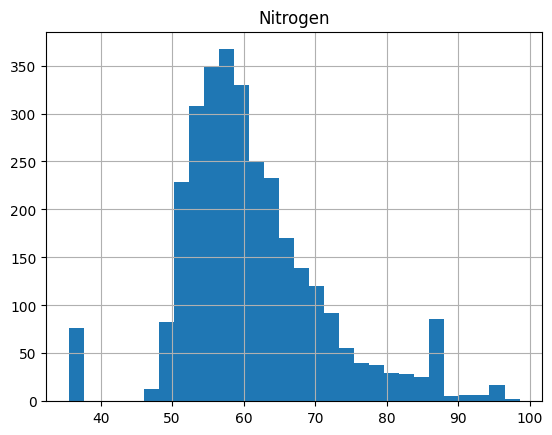

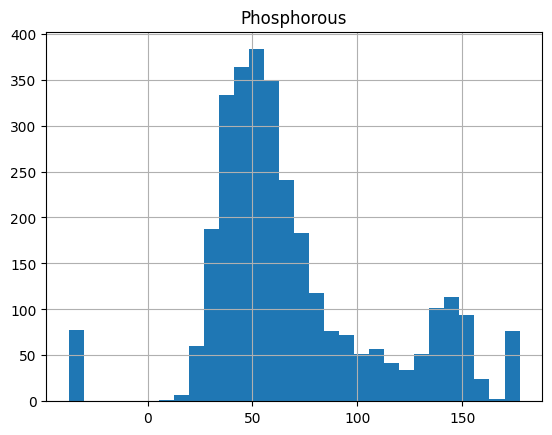

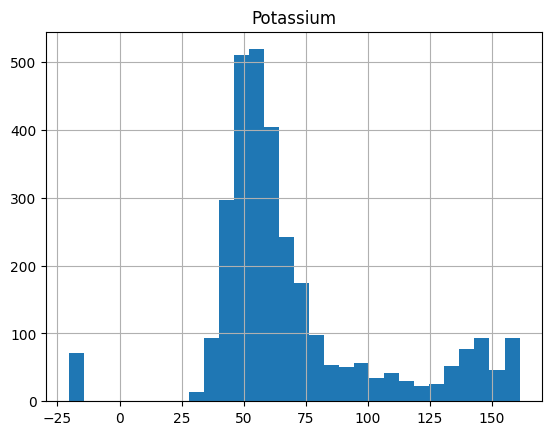

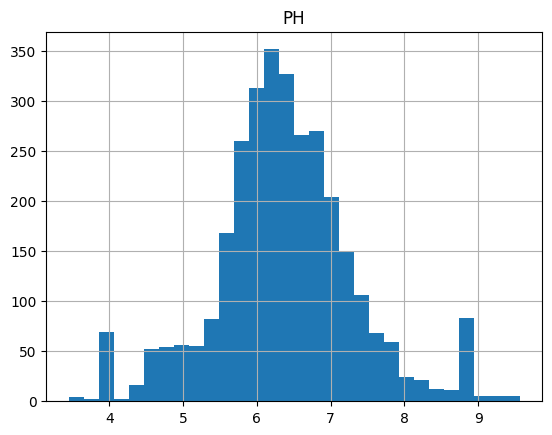

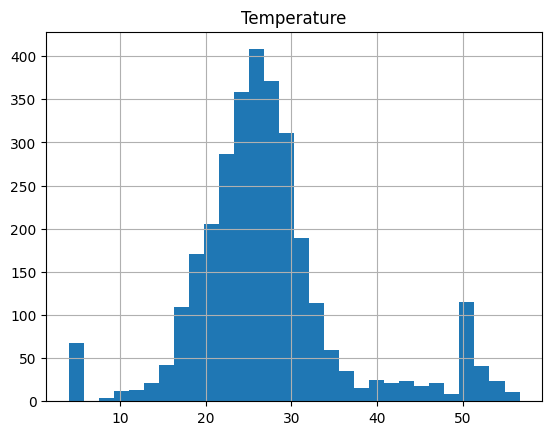

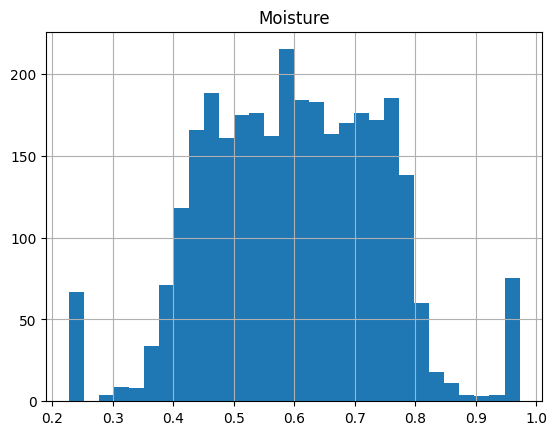

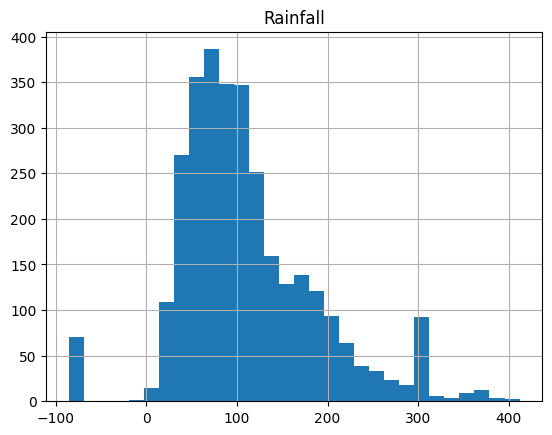

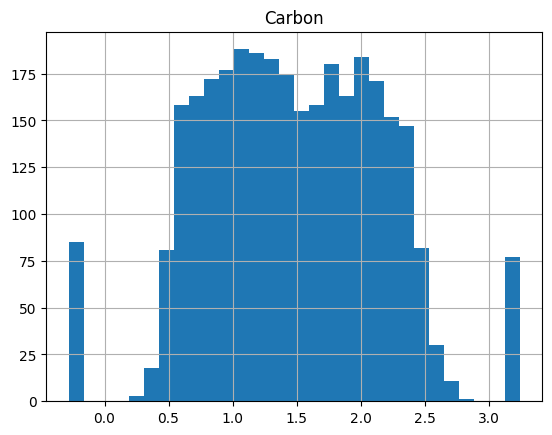

In [87]:
import matplotlib.pyplot as plt

numeric_cols = ['Nitrogen','Phosphorous','Potassium','PH','Temperature','Moisture','Rainfall','Carbon']
for col in numeric_cols:
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()


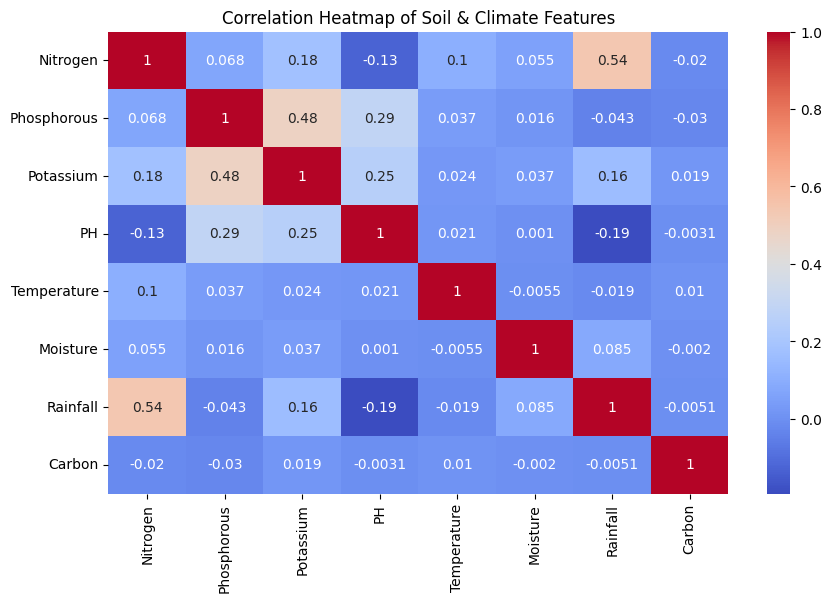

In [88]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Soil & Climate Features")
plt.show()


In [91]:
df.groupby('Crop')[['Nitrogen','Phosphorous','Potassium']].mean()


,Nitrogen,Phosphorous,Potassium
Crop,,,
Adzuki Beans,65.433255,67.684057,72.297003
Black gram,56.833970,96.738480,80.327387
Chickpea,52.141447,43.178866,67.109391
Coconut,74.548297,59.840189,66.266147
Coffee,63.536423,98.899037,105.090485
Cotton,58.615099,84.753458,71.460286
Ground Nut,61.224541,52.545000,57.743112
Jute,68.751720,95.634165,104.981508
Kidney Beans,52.538487,36.681506,50.966066


In [92]:
print(df.isnull().sum())


Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
Fertilizer     0
Remark         0
dtype: int64


In [93]:
# Numeric columns median se fill
numeric_cols = ['Nitrogen','Phosphorous','Potassium','PH','Temperature','Moisture','Rainfall','Carbon']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns mode se fill
df['Crop'] = df['Crop'].fillna(df['Crop'].mode()[0])
df['Soil'] = df['Soil'].fillna(df['Soil'].mode()[0])
df['Fertilizer'] = df['Fertilizer'].fillna(df['Fertilizer'].mode()[0])


In [94]:
df = df.drop_duplicates().reset_index(drop=True)


In [95]:
from sklearn.preprocessing import LabelEncoder

le_crop = LabelEncoder()
df['Crop_le'] = le_crop.fit_transform(df['Crop'])

le_soil = LabelEncoder()
df['Soil_le'] = le_soil.fit_transform(df['Soil'])

le_fert = LabelEncoder()
df['Fertilizer_le'] = le_fert.fit_transform(df['Fertilizer'])


In [96]:
import os

# data folder create if not exists
os.makedirs("data", exist_ok=True)

# ab safe save kar sakte ho
df.to_csv("data/fertilizer_clean.csv", index=False)
print("✅ Clean dataset saved in 'data/fertilizer_clean.csv'")


✅ Clean dataset saved in 'data/fertilizer_clean.csv'


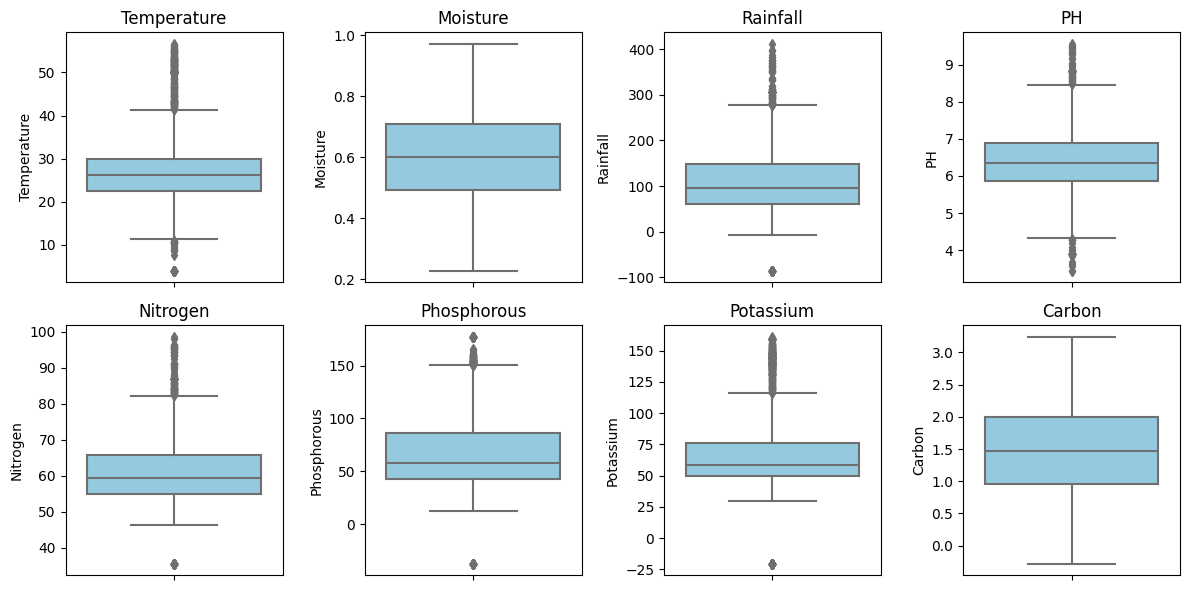

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ["Temperature", "Moisture", "Rainfall", "PH", 
                "Nitrogen", "Phosphorous", "Potassium", "Carbon"]

plt.figure(figsize=(12,6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)
plt.tight_layout()
plt.show()


In [98]:
# Step: Outlier Removal using IQR
numeric_cols = ["Temperature", "Moisture", "Rainfall", "PH", 
                "Nitrogen", "Phosphorous", "Potassium", "Carbon"]

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Condition: keep only non-outliers
df_clean = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
                (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original shape:", df.shape)
print("After outlier removal:", df_clean.shape)


Original shape: (3100, 15)
After outlier removal: (1761, 15)


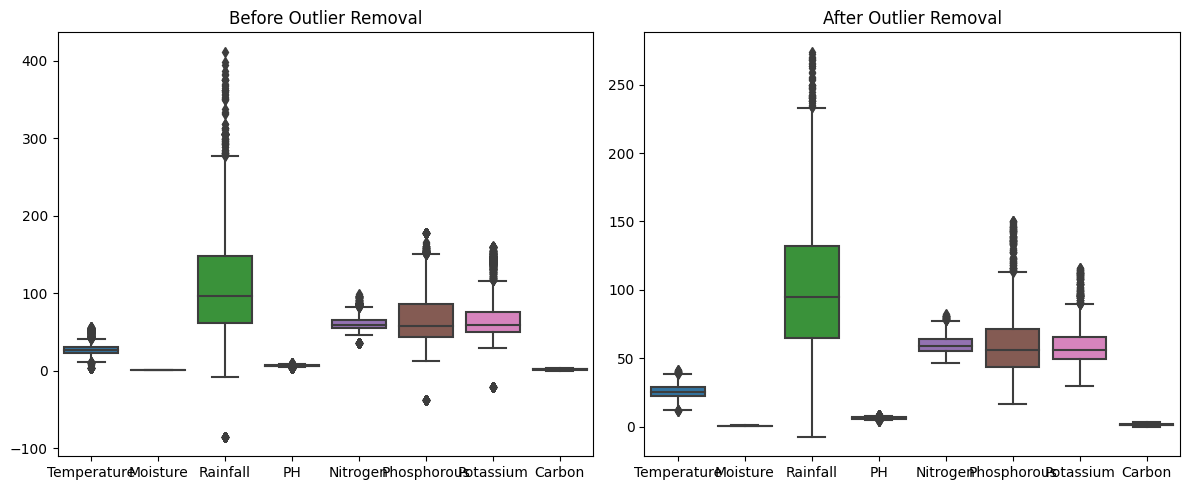

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df[numeric_cols])
plt.title("Before Outlier Removal")

plt.subplot(1,2,2)
sns.boxplot(data=df_clean[numeric_cols])
plt.title("After Outlier Removal")

plt.tight_layout()
plt.show()


In [100]:
!pip install -U scikit-learn imbalanced-learn


  Using cached scikit_learn-1.7.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.14.0-py3-none-any.whl.metadata (8.8 kB)
Using cached scikit_learn-1.7.2-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
Using cached imbalanced_learn-0.14.0-py3-none-any.whl (239 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.12.3
    Uninstalling imbalanced-learn-0.12.3:
      Successfully uninstalled imbalanced-learn-0.12.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incom

In [101]:
!pip install -U scikit-learn==1.5.2 imbalanced-learn==0.12.3


  Using cached scikit_learn-1.5.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached imbalanced_learn-0.12.3-py3-none-any.whl.metadata (8.3 kB)
Using cached scikit_learn-1.5.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.3 MB)
Using cached imbalanced_learn-0.12.3-py3-none-any.whl (258 kB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


In [102]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)


In [103]:

features = ['Nitrogen','Phosphorous','Potassium','PH',
            'Temperature','Moisture','Rainfall','Carbon',
            'Crop_le','Soil_le']   # numeric + encoded categorical

X = df[features]
y = df['Fertilizer_le']   # target



In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2480, 10)
Test shape: (620, 10)


In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Model define
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))


Random Forest Accuracy: 0.9919354838709677



Classification Report:

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        31
           1       1.00      1.00      1.00        75
           2       1.00      1.00      1.00       211
           3       1.00      1.00      1.00         6
           4       1.00      0.73      0.84        11
           5       1.00      1.00      1.00        36
           6       1.00      1.00      1.00        65
           7       0.95      1.00      0.97        19
           8       1.00      1.00      1.00        31
           9       0.99      0.99      0.99       135

    accuracy                           0.99       620
   macro avg       0.99      0.97      0.98       620
weighted avg       0.99      0.99      0.99       620



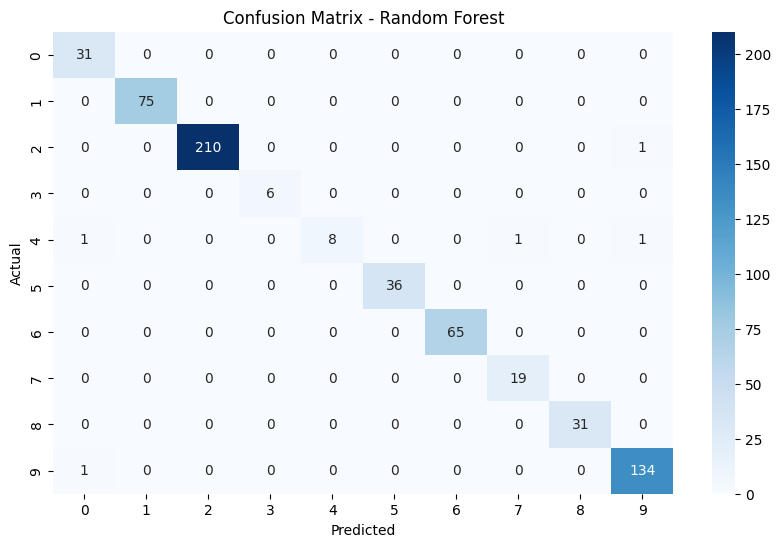

In [106]:
# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))


XGBoost Accuracy: 0.9838709677419355


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9919354838709677


In [33]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Model initialize
log_reg = LogisticRegression(max_iter=200)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred_lr = log_reg.predict(X_test)

# Accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", accuracy_lr)

# Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.7032258064516129

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.64      0.83      0.72        75
           2       0.84      0.91      0.87       211
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        11
           5       0.29      0.17      0.21        36
           6       0.71      0.71      0.71        65
           7       0.43      0.47      0.45        19
           8       0.78      0.58      0.67        31
           9       0.63      0.76      0.69       135

    accuracy                           0.70       620
   macro avg       0.43      0.44      0.43       620
weighted avg       0.64      0.70      0.67       620



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels wit

In [107]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Model initialize
svm_model = SVC(kernel='linear')   # linear kernel se start karte hain

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

# Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9387096774193548

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.74      0.79        31
           1       0.87      0.99      0.93        75
           2       0.99      0.99      0.99       211
           3       1.00      0.17      0.29         6
           4       1.00      1.00      1.00        11
           5       0.88      0.83      0.86        36
           6       0.97      0.97      0.97        65
           7       0.75      0.95      0.84        19
           8       1.00      0.90      0.95        31
           9       0.93      0.93      0.93       135

    accuracy                           0.94       620
   macro avg       0.92      0.85      0.85       620
weighted avg       0.94      0.94      0.94       620



In [108]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model initialize (yahan pe 5 neighbors rakhe hain)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", accuracy_knn)

# Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.5741935483870968

Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.16      0.15        31
           1       0.25      0.31      0.28        75
           2       0.86      0.95      0.90       211
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        11
           5       0.35      0.25      0.29        36
           6       0.68      0.72      0.70        65
           7       0.22      0.11      0.14        19
           8       0.62      0.16      0.26        31
           9       0.45      0.47      0.46       135

    accuracy                           0.57       620
   macro avg       0.36      0.31      0.32       620
weighted avg       0.56      0.57      0.56       620



In [109]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# SVM
from sklearn.svm import SVC
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)


lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


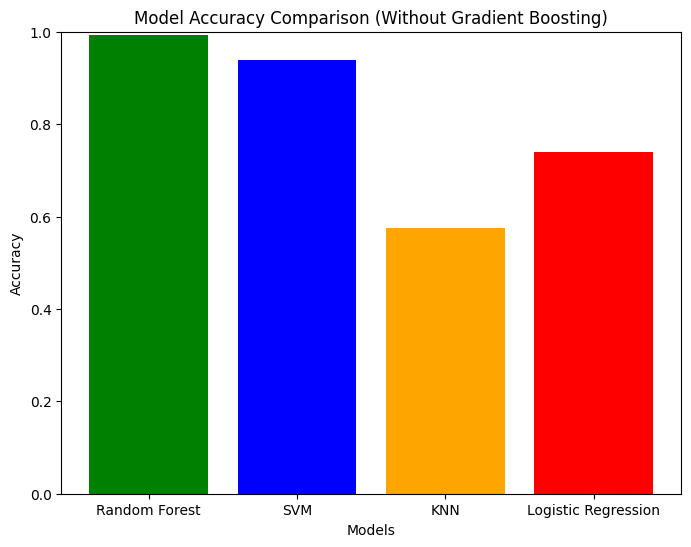

In [110]:
import matplotlib.pyplot as plt

# Accuracy values store karo
model_names = ["Random Forest", "SVM", "KNN", "Logistic Regression"]
accuracies = [accuracy_rf, accuracy_svm, accuracy_knn, accuracy_lr]

# Bar chart plot
plt.figure(figsize=(8,6))
plt.bar(model_names, accuracies, color=['green','blue','orange','red'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Without Gradient Boosting)")
plt.ylim(0,1)
plt.show()


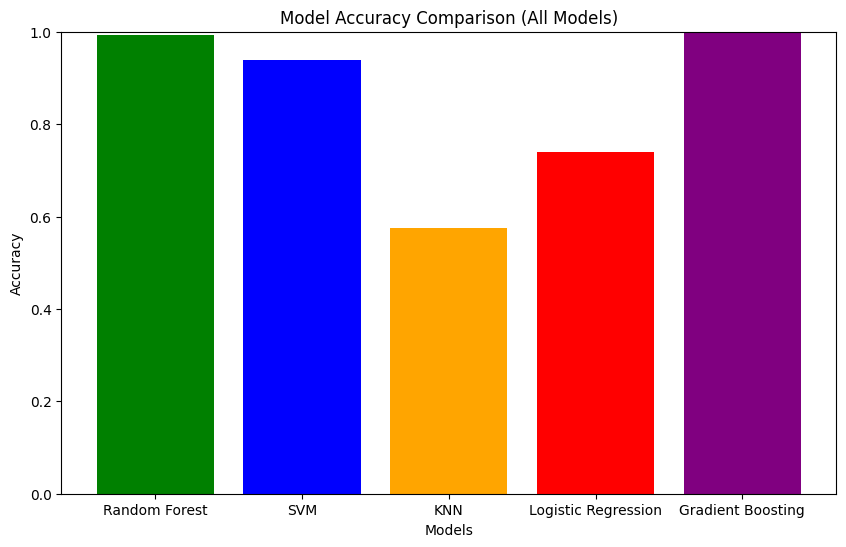

In [111]:
import matplotlib.pyplot as plt

# Accuracy values store karo
model_names = ["Random Forest", "SVM", "KNN", "Logistic Regression", "Gradient Boosting"]
accuracies = [accuracy_rf, accuracy_svm, accuracy_knn, accuracy_lr, accuracy_gb]

# Bar chart plot
plt.figure(figsize=(10,6))
plt.bar(model_names, accuracies, color=['green','blue','orange','red','purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (All Models)")
plt.ylim(0,1)
plt.show()


In [112]:
from sklearn.ensemble import RandomForestClassifier

X = df[['Temperature','Moisture','Rainfall','PH','Nitrogen','Phosphorous','Potassium','Carbon']]
y = df['Fertilizer']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)


RandomForestClassifier(random_state=42)

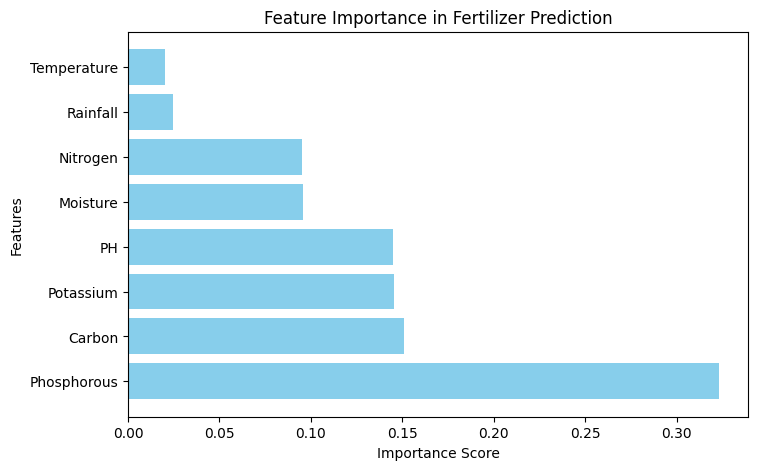

In [113]:
import matplotlib.pyplot as plt
import pandas as pd

importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
plt.title("Feature Importance in Fertilizer Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


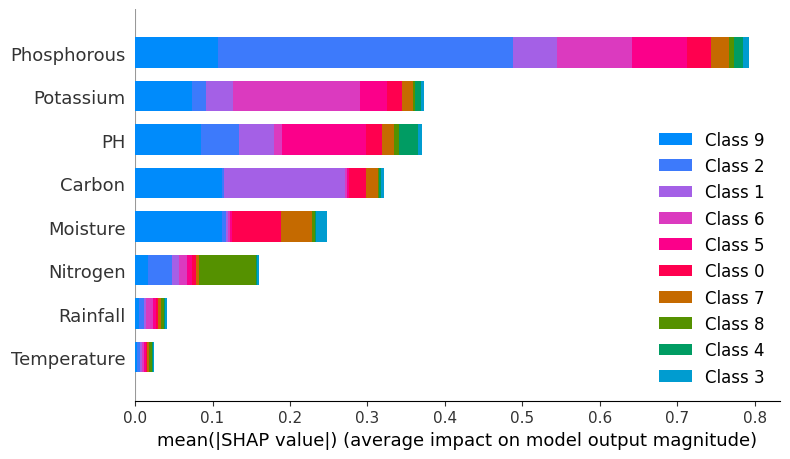

In [116]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X, plot_type="bar")


Predicted Fertilizer: Compost


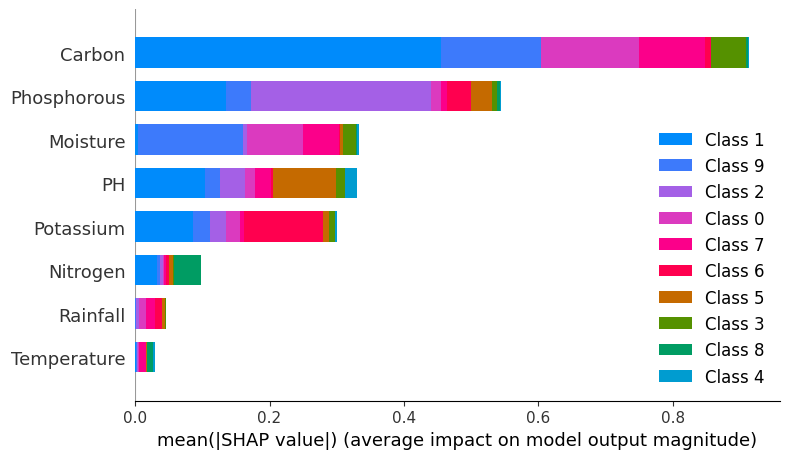

In [117]:
# Ek sample row select karte hain (pehla test sample)
sample = X.iloc[[0]]

# Predict fertilizer
predicted = rf.predict(sample)
print("Predicted Fertilizer:", predicted[0])

# SHAP values for this sample
shap_values_sample = explainer.shap_values(sample)

# Static summary plot for this one row
shap.summary_plot(shap_values_sample, sample)


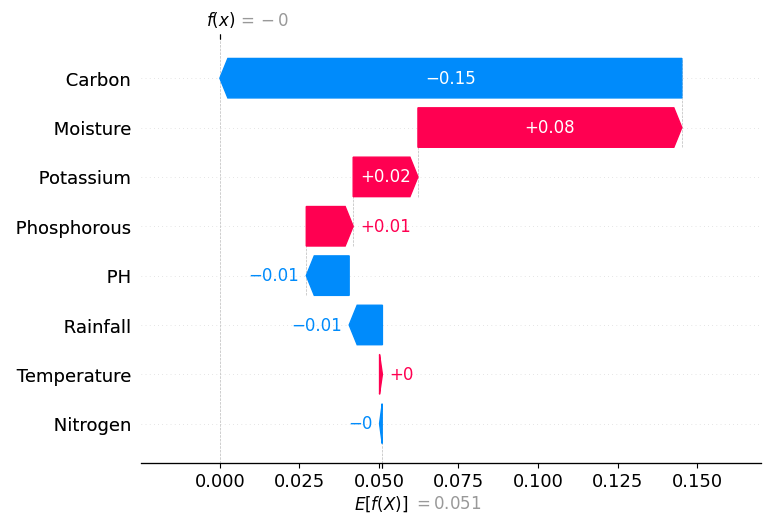

In [118]:
shap.plots._waterfall.waterfall_legacy(explainer.expected_value[0],
                                       shap_values_sample[0][0],
                                       feature_names=sample.columns,
                                       features=sample.iloc[0])


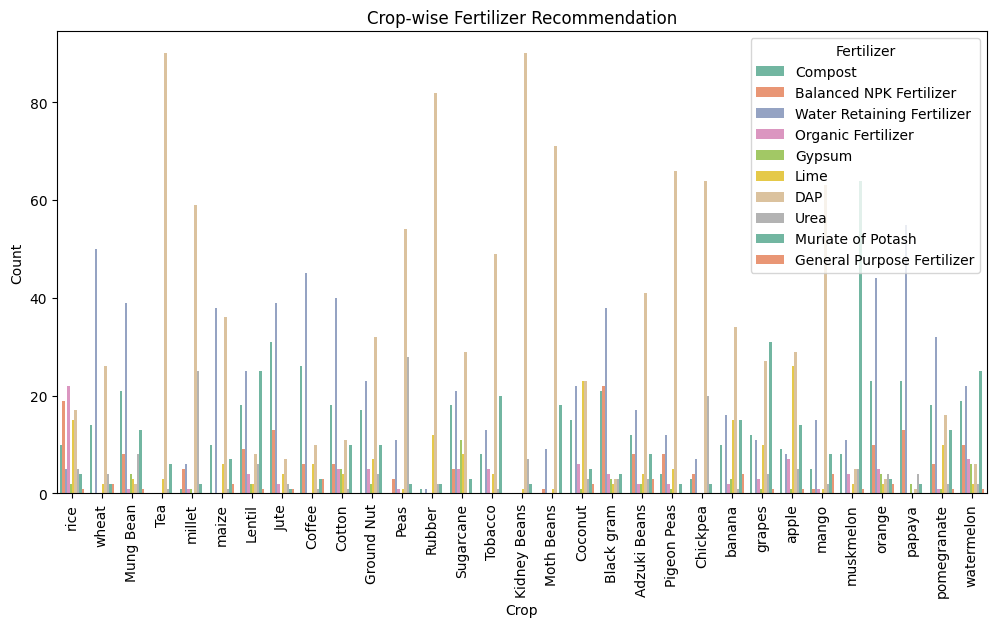

In [119]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crop vs Fertilizer ka countplot
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Crop", hue="Fertilizer", palette="Set2")
plt.title("Crop-wise Fertilizer Recommendation")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()


In [120]:
crop_fert_table = pd.crosstab(df["Crop"], df["Fertilizer"])
print(crop_fert_table.head(10))


Fertilizer    Balanced NPK Fertilizer  Compost  DAP  \
Crop                                                  
Adzuki Beans                        8       12   41   
Black gram                         22       21    3   
Chickpea                            4        3   64   
Coconut                             0       15   23   
Coffee                              6       26   10   
Cotton                              6       18   11   
Ground Nut                          0       17   32   
Jute                               13       31    7   
Kidney Beans                        0        0   90   
Lentil                              9       18    8   

Fertilizer    General Purpose Fertilizer  Gypsum  Lime  Muriate of Potash  \
Crop                                                                        
Adzuki Beans                           3       2     4                  8   
Black gram                             0       3     2                  4   
Chickpea                       

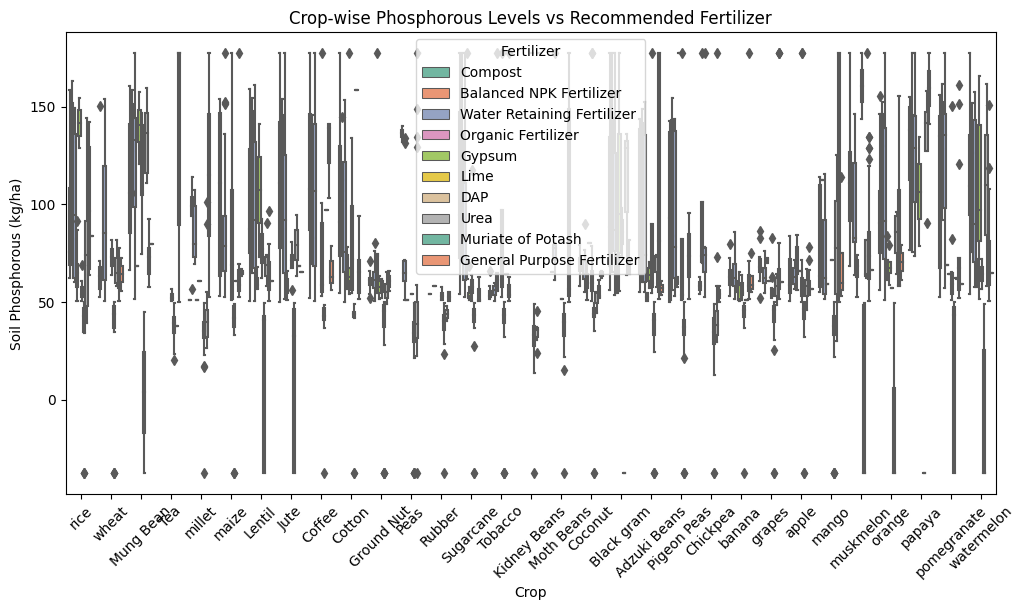

In [121]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Crop", y="Phosphorous", hue="Fertilizer", palette="Set2")
plt.title("Crop-wise Phosphorous Levels vs Recommended Fertilizer")
plt.ylabel("Soil Phosphorous (kg/ha)")
plt.xticks(rotation=45)
plt.show()


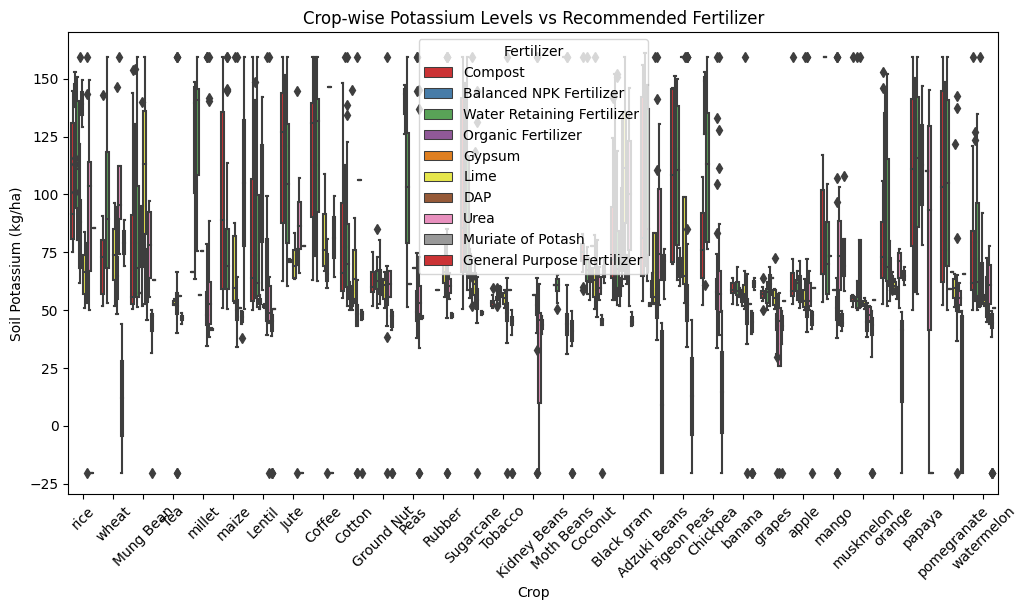

In [122]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Crop", y="Potassium", hue="Fertilizer", palette="Set1")
plt.title("Crop-wise Potassium Levels vs Recommended Fertilizer")
plt.ylabel("Soil Potassium (kg/ha)")
plt.xticks(rotation=45)
plt.show()


In [126]:
import shap

# SHAP explainer for trained Random Forest
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Function to generate Urdu explanation for a single sample
def explain_urdu(sample_row, predicted_fertilizer):
    # Compute SHAP values for this row
    shap_vals = explainer.shap_values(sample_row)
    
    # Find top 2 features contributing to prediction
    top_idx = np.argsort(np.abs(shap_vals[0][0]))[-2:][::-1]
    top_features = sample_row.columns[top_idx]
    
    explanations = []
    for f in top_features:
        val = sample_row[f].values[0]
        if val < X[f].median():
            explanations.append(f"{f} ka level kam hai")
        else:
            explanations.append(f"{f} ka level zyada hai")
    
    # Combine explanations into a sentence
    urdu_text = f"{predicted_fertilizer} recommend hua kyunki " + " aur ".join(explanations) + "."
    return urdu_text

# Example usage for first sample
sample = X.iloc[[0]]
predicted = rf.predict(sample)[0]
urdu_explanation = explain_urdu(sample, predicted)
print("Predicted Fertilizer:", predicted)
print("Urdu Explanation:", urdu_explanation)


Predicted Fertilizer: Compost
Urdu Explanation: Compost recommend hua kyunki Carbon ka level kam hai aur Moisture ka level zyada hai.
